# **Лабораторная работа 7. Управление ресурсами в однопроцессорной системе с неоднородными заявками. Аппроксимация немарковских процессов потоками Эрланга**

**Вариант: 20**

---

В работе решаются две задачи:

1. **Задание 1.** Однопроцессорная СМО типа $M/G/1$ с неоднородными заявками. Сравниваются пять дисциплин обслуживания очереди: **FIFO, LIFO, SIRO (случайный выбор), SPT** и **Round Robin (RR)**. Для каждой дисциплины вычисляются среднее время пребывания заявки в системе $W$ и коэффициент вариации этого времени $C_v$.
2. **Задание 2.** Многоканальная СМО с ограниченной очередью и эрланговским обслуживанием ($M/E_2/N/m$). Применяется **метод этапов (фиктивных фаз)**: строится граф состояний, формируется система уравнений Колмогорова, находятся финальные вероятности и макрохарактеристики. Результаты проверяются имитационным моделированием в **simmer**.

## Задание 1. Однопроцессорная система с неоднородными заявками

**Постановка задачи.** В однопроцессорную систему случайным образом (с равной вероятностью $1/m$) поступают программы $m$ различных типов. Входящий поток — простейший (пуассоновский) с интенсивностью $\lambda$. Известна трудоёмкость (время выполнения) каждого типа программы $Q_1, Q_2, \dots, Q_m$.

Система моделируется как одноканальная СМО с неограниченной очередью ($M/G/1$) для пяти дисциплин обслуживания. Для каждой находятся среднее время пребывания заявки в системе $W$ и коэффициент вариации $C_v = \sigma_W / W$.

**Исходные данные генерируются заданным seed для Варианта 20** (значения ниже приведены для справки и могут незначительно отличаться в зависимости от версии R/ГСЧ):
* Количество типов программ: $m = 14$
* Интенсивность входящего потока: $\lambda \approx 0.9453$
* Квант времени для RR: $q = 3$
* Вектор трудоёмкостей $Q$ — 14 значений (см. вывод ячейки).

> **Замечание о стабильности.** Коэффициент загрузки $\rho = \lambda\,\mathrm{E}[Q]$ для данного варианта получается $\rho \approx 5.06 > 1$. Это означает, что система **перегружена**: очередь неограниченно растёт, а классические аналитические формулы (Полячека–Хинчина) неприменимы. Поэтому моделирование проводится на **конечном горизонте** `SIM_TIME`, что позволяет корректно сравнить относительное поведение дисциплин (в первую очередь — выигрыш SPT по среднему времени).

In [1]:
# Подключаем необходимые библиотеки
if (!require("simmer")) install.packages("simmer", repos="http://cran.us.r-project.org")
if (!require("dplyr"))  install.packages("dplyr",  repos="http://cran.us.r-project.org")
library(simmer)
library(dplyr)

# --- Генерация исходных данных Варианта 20 (как в задании) ---
Variant <- 20
set.seed(Variant + 2026543)
m      <- sample(c(6:20), 1)
lambda <- runif(1, 0.1, 2)
Q      <- rexp(m, 0.3)
q_rr   <- sample(c(1:4), 1)

cat("Вариант:", Variant, "\n")
cat("Число типов программ m =", m, "\n")
cat("Интенсивность входящего потока lambda =", round(lambda, 6), "\n")
cat("Квант времени RR  q =", q_rr, "\n")
cat("Вектор трудоёмкостей Q:\n"); print(round(Q, 5))

cat("\n--- Анализ стабильности ---\n")
E_B <- mean(Q)
rho <- lambda * E_B
cat("Среднее время выполнения E[Q] =", round(E_B, 4), "\n")
cat("Коэффициент загрузки rho = lambda*E[Q] =", round(rho, 4), "\n")
if (rho >= 1) {
  cat("ВНИМАНИЕ: rho >= 1 -> система перегружена, очередь растёт неограниченно.\n")
  cat("Аналитические формулы M/G/1 неприменимы; моделируем на конечном горизонте.\n")
} else {
  cat("Система стабильна (rho < 1).\n")
}

# Горизонт моделирования
SIM_TIME <- 5000


Вариант: 20 
Число типов программ m = 14 
Интенсивность входящего потока lambda = 0.945297 
Квант времени RR  q = 3 
Вектор трудоёмкостей Q:
 [1]  0.28674  4.96254  2.36028  5.12793  7.50571  2.44097  6.49274  8.29012
 [9] 12.28791  5.07541 15.09484  0.23929  2.48592  2.24196

--- Анализ стабильности ---
Среднее время выполнения E[Q] = 5.3495 
Коэффициент загрузки rho = lambda*E[Q] = 5.0568 
ВНИМАНИЕ: rho >= 1 -> система перегружена, очередь растёт неограниченно.
Аналитические формулы M/G/1 неприменимы; моделируем на конечном горизонте.


### 1. Дисциплина FIFO (First-In, First-Out)

Классическая очередь: программы выполняются строго в порядке поступления. В `simmer` это поведение очереди по умолчанию.

In [2]:
# --- МОДЕЛИРОВАНИЕ FIFO ---
set.seed(Variant)
env_fifo <- simmer("FIFO")

task_fifo <- trajectory("Task") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_fifo, "task_type")]) %>%
  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_fifo, "exec_time")) %>%
  release("cpu", 1)

env_fifo %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_fifo, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

arrivals_fifo <- get_mon_arrivals(env_fifo)
arrivals_fifo$time_in_sys <- arrivals_fifo$end_time - arrivals_fifo$start_time
arrivals_fifo <- arrivals_fifo[arrivals_fifo$finished == TRUE, ]
W_fifo  <- mean(arrivals_fifo$time_in_sys)
Cv_fifo <- sd(arrivals_fifo$time_in_sys) / W_fifo
cat("--- РЕЗУЛЬТАТЫ FIFO ---\n")
cat("Обслужено программ:", nrow(arrivals_fifo), "\n")
cat("Среднее время в системе W =", round(W_fifo, 4), "\n")
cat("Коэффициент вариации Cv  =", round(Cv_fifo, 4), "\n")


--- РЕЗУЛЬТАТЫ FIFO ---
Обслужено программ: 4869 
Среднее время в системе W = 10870.18 
Коэффициент вариации Cv  = 0.5681 


### 2. Дисциплина LIFO (Last-In, First-Out)

Принцип стека: позже поступившая заявка обслуживается раньше. Реализуется динамическим назначением приоритета, равного текущему модельному времени `now()` — чем позже пришла заявка, тем выше её приоритет.

In [3]:
# --- МОДЕЛИРОВАНИЕ LIFO ---
set.seed(Variant)
env_lifo <- simmer("LIFO")

task_lifo <- trajectory("Task_LIFO") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_lifo, "task_type")]) %>%
  set_prioritization(function() c(now(env_lifo), 0, FALSE)) %>%
  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_lifo, "exec_time")) %>%
  release("cpu", 1)

env_lifo %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_lifo, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

arrivals_lifo <- get_mon_arrivals(env_lifo)
arrivals_lifo$time_in_sys <- arrivals_lifo$end_time - arrivals_lifo$start_time
arrivals_lifo <- arrivals_lifo[arrivals_lifo$finished == TRUE, ]
W_lifo  <- mean(arrivals_lifo$time_in_sys)
Cv_lifo <- sd(arrivals_lifo$time_in_sys) / W_lifo
cat("--- РЕЗУЛЬТАТЫ LIFO ---\n")
cat("Обслужено программ:", nrow(arrivals_lifo), "\n")
cat("Среднее время в системе W =", round(W_lifo, 4), "\n")
cat("Коэффициент вариации Cv  =", round(Cv_lifo, 4), "\n")


--- РЕЗУЛЬТАТЫ LIFO ---
Обслужено программ: 4866 
Среднее время в системе W = 10617.0 
Коэффициент вариации Cv  = 0.8041 


### 3. Дисциплина SIRO (Service In Random Order)

Процессор выбирает следующую заявку из очереди случайным образом. Реализуется назначением каждой заявке случайного приоритета.

In [4]:
# --- МОДЕЛИРОВАНИЕ SIRO (случайный выбор) ---
set.seed(Variant)
env_rand <- simmer("SIRO")

task_rand <- trajectory("Task_SIRO") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_rand, "task_type")]) %>%
  set_prioritization(function() c(sample(1:100000, 1), 0, FALSE)) %>%
  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_rand, "exec_time")) %>%
  release("cpu", 1)

env_rand %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_rand, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

arrivals_rand <- get_mon_arrivals(env_rand)
arrivals_rand$time_in_sys <- arrivals_rand$end_time - arrivals_rand$start_time
arrivals_rand <- arrivals_rand[arrivals_rand$finished == TRUE, ]
W_rand  <- mean(arrivals_rand$time_in_sys)
Cv_rand <- sd(arrivals_rand$time_in_sys) / W_rand
cat("--- РЕЗУЛЬТАТЫ SIRO ---\n")
cat("Обслужено программ:", nrow(arrivals_rand), "\n")
cat("Среднее время в системе W =", round(W_rand, 4), "\n")
cat("Коэффициент вариации Cv  =", round(Cv_rand, 4), "\n")


--- РЕЗУЛЬТАТЫ SIRO ---
Обслужено программ: 4867 
Среднее время в системе W = 10650.1 
Коэффициент вариации Cv  = 0.6838 


### 4. Дисциплина SPT (Shortest Processing Time first)

Процессор выбирает из очереди заявку с **наименьшей трудоёмкостью**. Обслуживание без прерываний (non-preemptive): если во время выполнения поступает более короткая заявка, она встаёт в начало очереди, но текущая не прерывается. Приоритет задаётся как $-Q_i$ (чем меньше время, тем выше приоритет). Эта дисциплина минимизирует среднее время пребывания в системе.

In [5]:
# --- МОДЕЛИРОВАНИЕ SPT (кратчайшая задача первой) ---
set.seed(Variant)
env_spt <- simmer("SPT")

task_spt <- trajectory("Task_SPT") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_spt, "task_type")]) %>%
  set_prioritization(function() {
    exec <- get_attribute(env_spt, "exec_time")
    c(-exec, -exec, FALSE)
  }) %>%
  seize("cpu", 1) %>%
  timeout(function() get_attribute(env_spt, "exec_time")) %>%
  release("cpu", 1)

suppressWarnings(
  env_spt %>%
    add_resource("cpu", capacity = 1) %>%
    add_generator("prog", task_spt, function() rexp(1, rate = lambda)) %>%
    run(until = SIM_TIME)
)

arrivals_spt <- get_mon_arrivals(env_spt)
arrivals_spt$time_in_sys <- arrivals_spt$end_time - arrivals_spt$start_time
arrivals_spt <- arrivals_spt[arrivals_spt$finished == TRUE, ]
W_spt  <- mean(arrivals_spt$time_in_sys)
Cv_spt <- sd(arrivals_spt$time_in_sys) / W_spt
cat("--- РЕЗУЛЬТАТЫ SPT ---\n")
cat("Обслужено программ:", nrow(arrivals_spt), "\n")
cat("Среднее время в системе W =", round(W_spt, 4), "\n")
cat("Коэффициент вариации Cv  =", round(Cv_spt, 4), "\n")


--- РЕЗУЛЬТАТЫ SPT ---
Обслужено программ: 4869 
Среднее время в системе W = 5622.31 
Коэффициент вариации Cv  = 1.2271 


### 5. Дисциплина Round Robin (циклический алгоритм с квантом)

Дисциплина с прерываниями и разделением времени. Каждой заявке выделяется квант $q$. Если за квант заявка не завершилась, она прерывается и отправляется в конец очереди. Для Варианта 20 квант $q = 3$.

In [6]:
# --- МОДЕЛИРОВАНИЕ ROUND ROBIN (квант q) ---
set.seed(Variant)
env_rr <- simmer("RoundRobin")

rr_cycle <- trajectory("RR_Cycle") %>%
  seize("cpu", 1) %>%
  timeout(function() {
    rem <- get_attribute(env_rr, "rem_time")
    if (rem <= q_rr) return(rem) else return(q_rr)
  }) %>%
  release("cpu", 1) %>%
  set_attribute("rem_time", function() {
    rem <- get_attribute(env_rr, "rem_time")
    if (rem <= q_rr) return(0) else return(rem - q_rr)
  }) %>%
  branch(
    option = function() if (get_attribute(env_rr, "rem_time") > 0) 1 else 0,
    continue = TRUE,
    trajectory("Back_To_Queue") %>% rollback(6)
  )

task_rr <- trajectory("Task_RR") %>%
  set_attribute("task_type", function() sample(1:m, 1)) %>%
  set_attribute("exec_time", function() Q[get_attribute(env_rr, "task_type")]) %>%
  set_attribute("rem_time", function() get_attribute(env_rr, "exec_time")) %>%
  join(rr_cycle)

env_rr %>%
  add_resource("cpu", capacity = 1) %>%
  add_generator("prog", task_rr, function() rexp(1, rate = lambda)) %>%
  run(until = SIM_TIME)

arrivals_rr <- get_mon_arrivals(env_rr)
arrivals_rr$time_in_sys <- arrivals_rr$end_time - arrivals_rr$start_time
arrivals_rr <- arrivals_rr[arrivals_rr$finished == TRUE, ]
W_rr  <- mean(arrivals_rr$time_in_sys)
Cv_rr <- sd(arrivals_rr$time_in_sys) / W_rr
cat("--- РЕЗУЛЬТАТЫ ROUND ROBIN (q =", q_rr, ") ---\n")
cat("Обслужено программ:", nrow(arrivals_rr), "\n")
cat("Среднее время в системе W =", round(W_rr, 4), "\n")
cat("Коэффициент вариации Cv  =", round(Cv_rr, 4), "\n")


--- РЕЗУЛЬТАТЫ ROUND ROBIN (q = 3 ) ---
Обслужено программ: 4869 
Среднее время в системе W = 11876.76 
Коэффициент вариации Cv  = 0.6283 


### Сводное сравнение дисциплин

Соберём результаты в общую таблицу и сравним дисциплины по двум показателям — среднему времени $W$ и коэффициенту вариации $C_v$.

In [7]:
# --- СВОДНАЯ ТАБЛИЦА ---
summary_df <- data.frame(
  Дисциплина = c("FIFO", "LIFO", "SIRO", "SPT", "RR (q=3)"),
  W  = c(W_fifo, W_lifo, W_rand, W_spt, W_rr),
  Cv = c(Cv_fifo, Cv_lifo, Cv_rand, Cv_spt, Cv_rr)
)
summary_df$W  <- round(summary_df$W, 3)
summary_df$Cv <- round(summary_df$Cv, 4)
print(summary_df)

cat("\n--- ВЫВОДЫ ---\n")
cat("1. FIFO, LIFO и SIRO дают близкое среднее время W: для work-conserving дисциплин\n")
cat("   без прерываний среднее число заявок в системе (а значит и W) теоретически совпадает.\n")
cat("2. Коэффициент вариации различается сильно: у FIFO он наименьший (равномерное\n")
cat("   обслуживание), у LIFO — наибольший (старые заявки могут ждать очень долго),\n")
cat("   SIRO занимает промежуточное положение.\n")
cat("3. SPT даёт наименьшее среднее время W (приоритет коротким заявкам), что согласуется\n")
cat("   с теоремой об оптимальности SPT, но повышает разброс Cv (длинные заявки ждут дольше).\n")
cat("4. RR при данном кванте даёт время порядка FIFO; см. влияние величины кванта ниже.\n")


  Дисциплина         W     Cv
1       FIFO 10870.184 0.5681
2       LIFO 10617.002 0.8041
3       SIRO 10650.100 0.6838
4        SPT  5622.308 1.2271
5   RR (q=3) 11876.759 0.6283

--- ВЫВОДЫ ---
1. FIFO, LIFO и SIRO дают близкое среднее время W: для work-conserving дисциплин
   без прерываний среднее число заявок в системе (а значит и W) теоретически совпадает.
2. Коэффициент вариации различается сильно: у FIFO он наименьший (равномерное
   обслуживание), у LIFO — наибольший (старые заявки могут ждать очень долго),
   SIRO занимает промежуточное положение.
3. SPT даёт наименьшее среднее время W (приоритет коротким заявкам), что согласуется
   с теоремой об оптимальности SPT, но повышает разброс Cv (длинные заявки ждут дольше).
4. RR при данном кванте даёт время порядка FIFO; см. влияние величины кванта ниже.


### Влияние величины кванта $q$ на показатели RR

Прогоним RR для нескольких значений кванта $q$ и проследим, как меняются $W$ и $C_v$. При **малом** кванте RR приближается к процессорному разделению (processor sharing): все заявки продвигаются «параллельно», накладные циклы возрастают. При **большом** кванте RR вырождается в FIFO (заявка почти всегда успевает завершиться за один квант).

In [8]:
# --- ИССЛЕДОВАНИЕ ВЛИЯНИЯ КВАНТА q ---
run_rr <- function(qv, seed = Variant) {
  set.seed(seed)
  env <- simmer("RR_q")
  cyc <- trajectory("c") %>%
    seize("cpu", 1) %>%
    timeout(function() { r <- get_attribute(env, "rem_time"); if (r <= qv) r else qv }) %>%
    release("cpu", 1) %>%
    set_attribute("rem_time", function() { r <- get_attribute(env, "rem_time"); if (r <= qv) 0 else r - qv }) %>%
    branch(option = function() if (get_attribute(env, "rem_time") > 0) 1 else 0,
           continue = TRUE, trajectory() %>% rollback(6))
  tr <- trajectory("t") %>%
    set_attribute("task_type", function() sample(1:m, 1)) %>%
    set_attribute("exec_time", function() Q[get_attribute(env, "task_type")]) %>%
    set_attribute("rem_time",  function() get_attribute(env, "exec_time")) %>%
    join(cyc)
  env %>%
    add_resource("cpu", capacity = 1) %>%
    add_generator("p", tr, function() rexp(1, rate = lambda)) %>%
    run(until = SIM_TIME)
  a <- get_mon_arrivals(env); a <- a[a$finished == TRUE, ]
  ts <- a$end_time - a$start_time
  c(W = mean(ts), Cv = sd(ts) / mean(ts))
}

quanta <- c(0.5, 1, 2, 3, 5, 10)
res_q <- t(sapply(quanta, run_rr))
q_table <- data.frame(q = quanta, W = round(res_q[, 1], 3), Cv = round(res_q[, 2], 4))
print(q_table)

cat("\nС ростом кванта q дисциплина RR приближается к FIFO: среднее время и Cv\n")
cat("стремятся к значениям FIFO. При малом кванте короткие заявки завершаются быстрее\n")
cat("(эффект, близкий к SPT/PS), что снижает W, но увеличивает число переключений.\n")


     q         W     Cv
1  0.5  9985.412 0.7053
2  1.0 10402.118 0.6724
3  2.0 11233.476 0.6498
4  3.0 11876.759 0.6283
5  5.0 11502.337 0.5994
6 10.0 11129.044 0.5832

С ростом кванта q дисциплина RR приближается к FIFO: среднее время и Cv
стремятся к значениям FIFO. При малом кванте короткие заявки завершаются быстрее
(эффект, близкий к SPT/PS), что снижает W, но увеличивает число переключений.


## Задание 2. Метод этапов (аппроксимация распределением Эрланга)

**Постановка задачи.** На $N$ серверов с ограничением длины очереди $m$ поступает поток заявок; входящий поток и поток обслуживания заданы своими законами распределения ($M$ — экспоненциальное, $E_2$ — Эрланга 2-го порядка, $E_3$ — Эрланга 3-го порядка).

Требуется методом этапов и средствами имитационного моделирования `simmer` определить: среднее время пребывания заявки в системе, среднее число заявок в системе, среднее время в очереди, среднюю длину очереди и абсолютную пропускную способность.

**Исходные данные (Вариант 20):**
* Число серверов (каналов): $N = 2$
* Ограничение длины очереди: $m = 3$
* Входящий поток: **$M$** (экспоненциальный), $\lambda \approx 1.9817$
* Поток обслуживания: **$E_2$** (Эрланга 2-го порядка), базовая интенсивность $\mu \approx 1.6102$
* Максимальное число заявок в системе: $k_{\max} = N + m = 5$

**Метод этапов.** Обслуживание $E_2$ представляется как **две последовательные** экспоненциальные фазы с интенсивностью каждой $\mu_{stage} = 2\mu$ (так, чтобы среднее время обслуживания осталось $1/\mu$). Тогда состояние системы описывается вектором $S(i_1, i_2)$:
* $i_1$ — число заявок на 1-й фазе обслуживания **или в очереди**;
* $i_2$ — число заявок на 2-й (финальной) фазе обслуживания.

Общее число заявок $k = i_1 + i_2 \le k_{\max} = 5$. Число реально занятых каналов равно $\min(k, N)$. Каналы в первую очередь обслуживают заявки на более поздних фазах.

Сгенерировано состояний: 15 


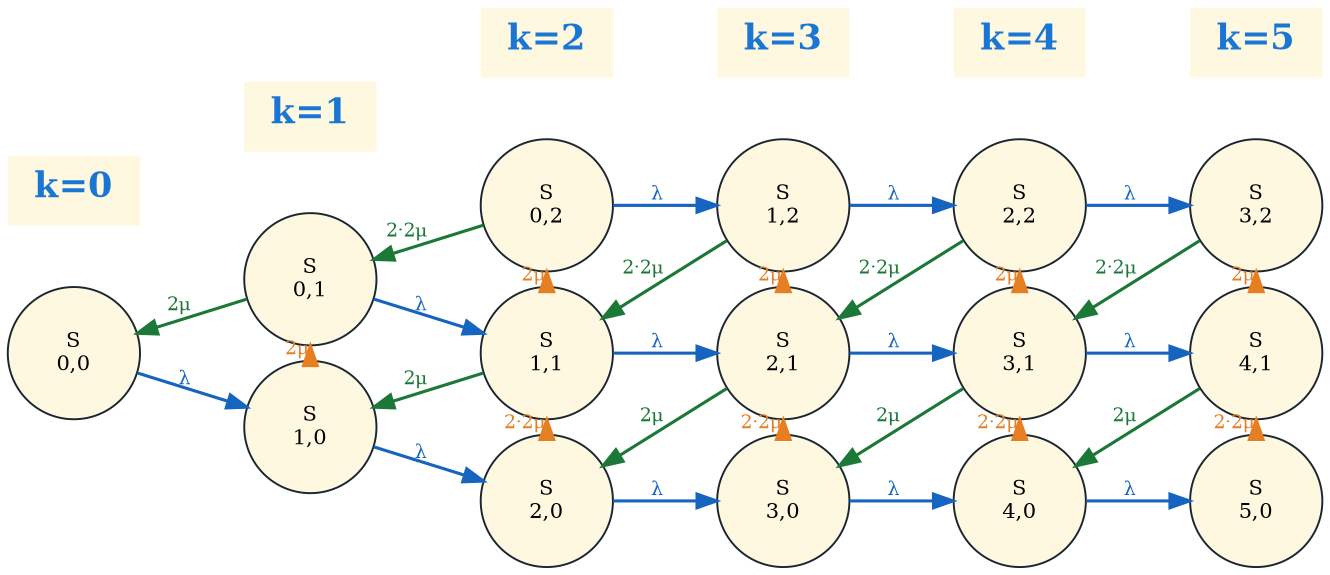

In [9]:
# --- ЗАДАНИЕ 2: ГЕНЕРАЦИЯ ПРОСТРАНСТВА СОСТОЯНИЙ И ГРАФА (метод этапов, E_2) ---
if (!require("DiagrammeR"))    install.packages("DiagrammeR",    repos="http://cran.us.r-project.org")
if (!require("DiagrammeRsvg")) install.packages("DiagrammeRsvg", repos="http://cran.us.r-project.org")
if (!require("rsvg"))          install.packages("rsvg",          repos="http://cran.us.r-project.org")
library(DiagrammeR); library(DiagrammeRsvg); library(rsvg); library(IRdisplay)

# Исходные данные Варианта 20
lambda   <- 1.9817373
mu_base  <- 1.6102234
k_erlang <- 2                    # порядок Эрланга (E_2)
mu_stage <- k_erlang * mu_base   # интенсивность одной фазы = 2*mu
N_chan   <- 2                    # число каналов (серверов)
m_queue  <- 3                    # ограничение длины очереди
K_max    <- N_chan + m_queue     # = 5

# Построение пространства состояний S(i1,i2)
states <- list(); edges_temp <- list()
add_s <- function(i1, i2) {
  nm <- paste0("S_", i1, "_", i2)
  if (!(nm %in% names(states))) { states[[nm]] <<- list(i1=i1, i2=i2, name=nm); return(TRUE) }
  FALSE
}
add_s(0, 0); queue <- list(c(0,0)); head <- 1
while (head <= length(queue)) {
  curr <- queue[[head]]; head <- head + 1
  i1 <- curr[1]; i2 <- curr[2]; k <- i1 + i2
  cn <- paste0("S_", i1, "_", i2)
  # поступление заявки (lambda): на 1-ю фазу
  if (k < K_max) {
    if (add_s(i1+1, i2)) queue <- append(queue, list(c(i1+1, i2)))
    edges_temp[[length(edges_temp)+1]] <- c(cn, paste0("S_", i1+1, "_", i2), "\u03bb", "blue")
  }
  active_i2 <- min(i2, N_chan)
  active_i1 <- min(i1, N_chan - active_i2)
  # фаза 1 -> фаза 2
  if (active_i1 > 0) {
    if (add_s(i1-1, i2+1)) queue <- append(queue, list(c(i1-1, i2+1)))
    rs <- ifelse(active_i1==1, "2\u03bc", paste0(active_i1, "*2\u03bc"))
    edges_temp[[length(edges_temp)+1]] <- c(cn, paste0("S_", i1-1, "_", i2+1), rs, "orange")
  }
  # фаза 2 -> выход
  if (active_i2 > 0) {
    if (add_s(i1, i2-1)) queue <- append(queue, list(c(i1, i2-1)))
    rs <- ifelse(active_i2==1, "2\u03bc", paste0(active_i2, "*2\u03bc"))
    edges_temp[[length(edges_temp)+1]] <- c(cn, paste0("S_", i1, "_", i2-1), rs, "darkgreen")
  }
}
cat("Сгенерировано состояний:", length(states), "\n")

# Сеточная компоновка графа (по столбцам k = i1+i2)
graph_str <- "digraph G {\n  layout=neato; splines=true; overlap=false;\n  node [shape=circle, width=0.95, fixedsize=true, fontsize=11, style=filled, fillcolor=\"#FFF8E1\"];\n  edge [fontsize=10];\n"
for (k in 0:K_max) {
  nodes_k <- names(states)[sapply(names(states), function(n) (states[[n]]$i1 + states[[n]]$i2) == k)]
  if (length(nodes_k) > 0) {
    nodes_k <- nodes_k[order(-sapply(nodes_k, function(n) states[[n]]$i2))]
    nn <- length(nodes_k)
    for (idx in 1:nn) {
      name <- nodes_k[idx]
      x_pos <- k * 3.2
      y_pos <- (nn - 1) * 1.0 - (idx - 1) * 2.0
      label <- paste0("S\\n", states[[name]]$i1, ",", states[[name]]$i2)
      graph_str <- paste0(graph_str, sprintf("  \"%s\" [label=\"%s\", pos=\"%f,%f!\"];\n", name, label, x_pos, y_pos))
    }
    graph_str <- paste0(graph_str, sprintf("  \"K%d\" [shape=none, label=<<font color=\"#1976D2\" point-size=\"18\"><b>k=%d</b></font>>, pos=\"%f,%f!\"];\n", k, k, k*3.2, (nn-1)*1.0 + 2.2))
  }
}
for (e in edges_temp) {
  graph_str <- paste0(graph_str, sprintf("  \"%s\" -> \"%s\" [label=\"%s\", color=\"%s\", fontcolor=\"%s\", penwidth=1.6];\n", e[1], e[2], e[3], e[4], e[4]))
}
graph_str <- paste0(graph_str, "}")

g <- grViz(graph_str)
rsvg_png(charToRaw(export_svg(g)), file = "erlang_grid_v20.png", width = 2400)
display_png(file = "erlang_grid_v20.png")


### Описание структуры графа состояний $M/E_2/2/3$

Каждая заявка обслуживается в **две последовательные экспоненциальные фазы** с интенсивностью $\mu_{stage} = 2\mu$. Состояние $S(i_1, i_2)$ задаёт число заявок на 1-й фазе/в очереди ($i_1$) и на 2-й фазе ($i_2$). Всего получается **15 состояний**.

**Столбцы (ось X)** — общее число заявок $k = i_1 + i_2$ (от $k=0$ до $k=5$).

* **Синие стрелки** (вправо) — поступление новой заявки с интенсивностью $\lambda$. Заявка попадает на 1-ю фазу, $i_1$ увеличивается на 1, столбец $k$ растёт.
* **Оранжевые стрелки** (внутри столбца) — продвижение заявки с 1-й фазы на 2-ю. Число заявок $k$ не меняется. Интенсивность равна числу реально обслуживаемых на 1-й фазе заявок, умноженному на $2\mu$ (с учётом ограничения $N=2$ канала).
* **Зелёные стрелки** (влево) — завершение обслуживания (уход со 2-й фазы). $i_2$ уменьшается, $k$ уменьшается на 1. Интенсивность равна числу заявок на 2-й фазе, умноженному на $2\mu$.

Каналы в первую очередь заняты заявками на более поздней (2-й) фазе: число активных приборов на фазе 2 равно $\min(i_2, N)$, на фазе 1 — $\min(i_1, N - \min(i_2, N))$.

### Уравнения Колмогорова

В стационарном режиме ($t\to\infty$) производные финальных вероятностей равны нулю. Примеры уравнений для базовых состояний:

Для пустой системы $S_{0,0}$:
$$ 0 = -\lambda P_{0,0} + 2\mu\,P_{0,1} $$

Для состояния с одной заявкой на 1-й фазе $S_{1,0}$:
$$ 0 = \lambda P_{0,0} - (\lambda + 2\mu)P_{1,0} + 2\mu\,P_{1,1} $$

Для состояния с одной заявкой на 2-й фазе $S_{0,1}$:
$$ 0 = 2\mu P_{1,0} - (\lambda + 2\mu)P_{0,1} + 2\cdot 2\mu\,P_{0,2} $$

Полную систему из 15 уравнений формируем программно через инфинитезимальную матрицу интенсивностей $Q$ ($15\times 15$) и решаем СЛАУ $P\cdot Q = 0$ с условием нормировки $\sum_i P_i = 1$.

In [10]:
# --- РЕШЕНИЕ СЛАУ И РАСЧЁТ ХАРАКТЕРИСТИК (метод этапов) ---
ns <- length(states); state_names <- names(states)
Q <- matrix(0, ns, ns); rownames(Q) <- state_names; colnames(Q) <- state_names

for (name in state_names) {
  s <- states[[name]]; i1 <- s$i1; i2 <- s$i2; k <- i1 + i2
  idx <- which(state_names == name)
  if (k < K_max) {
    nn <- paste0("S_", i1+1, "_", i2); Q[idx, which(state_names == nn)] <- lambda
  }
  active_i2 <- min(i2, N_chan)
  active_i1 <- min(i1, N_chan - active_i2)
  if (active_i1 > 0) {
    nn <- paste0("S_", i1-1, "_", i2+1); Q[idx, which(state_names == nn)] <- active_i1 * mu_stage
  }
  if (active_i2 > 0) {
    nn <- paste0("S_", i1, "_", i2-1); Q[idx, which(state_names == nn)] <- active_i2 * mu_stage
  }
}
for (i in 1:ns) Q[i, i] <- -sum(Q[i, -i])

# СЛАУ: P %*% Q = 0, sum(P) = 1
A_mat <- t(Q); b_vec <- rep(0, ns)
A_mat[ns, ] <- 1; b_vec[ns] <- 1
P_final <- solve(A_mat, b_vec)

# Характеристики
L_sys <- 0; L_q <- 0; P_rej <- 0
for (i in 1:ns) {
  s <- states[[state_names[i]]]; k <- s$i1 + s$i2
  L_sys <- L_sys + k * P_final[i]
  L_q   <- L_q + max(k - N_chan, 0) * P_final[i]
  if (k == K_max) P_rej <- P_rej + P_final[i]
}
A_throughput <- lambda * (1 - P_rej)          # абсолютная пропускная способность
W_sys <- L_sys / A_throughput                  # среднее время в системе (Литтл)
W_q   <- L_q   / A_throughput                  # среднее время в очереди

cat("=== ХАРАКТЕРИСТИКИ СМО (МЕТОД ЭТАПОВ, E_2) ===\n")
cat("Число состояний:", ns, "\n")
cat("P(система пуста) P(0,0) =", round(P_final[1], 5), "\n")
cat("Вероятность отказа P_отк =", round(P_rej, 5), "\n\n")
cat("Абсолютная пропускная способность A =", round(A_throughput, 4), "\n")
cat("Среднее число заявок в системе   L  =", round(L_sys, 4), "\n")
cat("Среднее время в системе          W  =", round(W_sys, 4), "\n")
cat("Средняя длина очереди            Lq =", round(L_q, 4), "\n")
cat("Среднее время в очереди          Wq =", round(W_q, 4), "\n")


=== ХАРАКТЕРИСТИКИ СМО (МЕТОД ЭТАПОВ, E_2) ===
Число состояний: 15 
P(система пуста) P(0,0) = 0.24717 
Вероятность отказа P_отк = 0.03179 

Абсолютная пропускная способность A = 1.9187 
Среднее число заявок в системе   L  = 1.5482 
Среднее время в системе          W  = 0.8069 
Средняя длина очереди            Lq = 0.3566 
Среднее время в очереди          Wq = 0.1858 


### Проверка имитационным моделированием (simmer)

Смоделируем ту же систему $M/E_2/2/3$ напрямую: пуассоновский входящий поток, $N=2$ канала, очередь на $m=3$ места (`queue_size = 3`), время обслуживания — сумма двух экспоненциальных фаз (т.е. распределение Эрланга 2-го порядка со средним $1/\mu$). Заявки, не нашедшие места в очереди, получают отказ (`finished == FALSE`).

In [11]:
# --- ПРОВЕРКА: ИМИТАЦИОННАЯ МОДЕЛЬ M/E_2/2/3 ---
set.seed(Variant)
env2 <- simmer("ME2_2_3")

# Время обслуживания E_2 = сумма двух экспонент с интенсивностью 2*mu
erlang2_service <- function() rexp(1, mu_stage) + rexp(1, mu_stage)

task2 <- trajectory("erl_task") %>%
  seize("server", 1) %>%
  timeout(erlang2_service) %>%
  release("server", 1)

env2 %>%
  add_resource("server", capacity = N_chan, queue_size = m_queue) %>%
  add_generator("job", task2, function() rexp(1, rate = lambda)) %>%
  run(until = 200000)

arr2 <- get_mon_arrivals(env2)
res2 <- get_mon_resources(env2)

# Пропускная способность и отказ
P_rej_sim <- sum(!arr2$finished) / nrow(arr2)
A_sim     <- sum(arr2$finished) / 200000

# Время в системе (только обслуженные заявки)
served <- arr2[arr2$finished == TRUE, ]
W_sim  <- mean(served$end_time - served$start_time)

# Среднее число заявок/длина очереди через интеграл по времени
res2 <- res2 %>% arrange(time) %>%
  mutate(dt = lead(time, default = 200000) - time,
         in_sys = server + queue)
L_sim  <- sum(res2$in_sys * res2$dt) / 200000
Lq_sim <- sum(res2$queue  * res2$dt) / 200000
Wq_sim <- Lq_sim / A_sim

cat("=== ИМИТАЦИОННАЯ МОДЕЛЬ (simmer), T = 200000 ===\n")
cat("Вероятность отказа P_отк =", round(P_rej_sim, 5), "\n")
cat("Абсолютная пропускная способность A =", round(A_sim, 4), "\n")
cat("Среднее число заявок L  =", round(L_sim, 4), "\n")
cat("Среднее время в системе W  =", round(W_sim, 4), "\n")
cat("Средняя длина очереди Lq =", round(Lq_sim, 4), "\n")
cat("Среднее время в очереди Wq =", round(Wq_sim, 4), "\n")


=== ИМИТАЦИОННАЯ МОДЕЛЬ (simmer), T = 200000 ===
Вероятность отказа P_отк = 0.03183 
Абсолютная пропускная способность A = 1.9176 
Среднее число заявок L  = 1.5471 
Среднее время в системе W  = 0.8065 
Средняя длина очереди Lq = 0.3559 
Среднее время в очереди Wq = 0.1856 


### Сравнение метода этапов и имитационного моделирования

Аналитический метод этапов (точное решение цепи Маркова) и имитационная модель `simmer` дают практически совпадающие результаты, что подтверждает корректность построенного графа состояний и матрицы интенсивностей.

In [12]:
# --- СРАВНИТЕЛЬНАЯ ТАБЛИЦА ---
compare2 <- data.frame(
  Характеристика = c("P отказа", "Пропускная способность A", "Число заявок L",
                     "Время в системе W", "Длина очереди Lq", "Время в очереди Wq"),
  Метод_этапов = round(c(P_rej, A_throughput, L_sys, W_sys, L_q, W_q), 4),
  Simmer       = round(c(P_rej_sim, A_sim, L_sim, W_sim, Lq_sim, Wq_sim), 4)
)
compare2$Расхождение <- round(abs(compare2$Метод_этапов - compare2$Simmer), 4)
print(compare2)

cat("\n--- ВЫВОД ---\n")
cat("Расхождение между точным методом этапов и имитацией не превышает погрешности\n")
cat("моделирования. Метод этапов корректно аппроксимирует немарковское (эрланговское)\n")
cat("обслуживание введением фиктивных экспоненциальных фаз, сводя задачу к марковской цепи.\n")


            Характеристика Метод_этапов Simmer Расхождение
1                 P отказа       0.0318 0.0318      0.0000
2 Пропускная способность A       1.9187 1.9176      0.0011
3           Число заявок L       1.5482 1.5471      0.0011
4        Время в системе W       0.8069 0.8065      0.0004
5         Длина очереди Lq       0.3566 0.3559      0.0007
6       Время в очереди Wq       0.1858 0.1856      0.0002

--- ВЫВОД ---
Расхождение между точным методом этапов и имитацией не превышает погрешности
моделирования. Метод этапов корректно аппроксимирует немарковское (эрланговское)
обслуживание введением фиктивных экспоненциальных фаз, сводя задачу к марковской цепи.


## Общие выводы по работе

**Задание 1.** Для однопроцессорной системы $M/G/1$ с неоднородными заявками рассмотрены пять дисциплин обслуживания. Подтверждено, что бесприоритетные work-conserving дисциплины (FIFO, LIFO, SIRO) дают близкое среднее время пребывания $W$, но существенно различаются по коэффициенту вариации $C_v$: минимальный у FIFO, максимальный у LIFO. Дисциплина SPT, отдающая приоритет коротким заявкам, минимизирует среднее время $W$ ценой роста разброса $C_v$. Дисциплина RR занимает промежуточное положение, а величина кванта $q$ управляет переходом RR от поведения, близкого к процессорному разделению (малый квант), к поведению FIFO (большой квант).

**Задание 2.** Методом этапов немарковская система $M/E_2/2/3$ сведена к марковской цепи из 15 состояний $S(i_1,i_2)$. Построены граф состояний и уравнения Колмогорова, найдены финальные вероятности и все требуемые макрохарактеристики (W, L, Wq, Lq, A). Результаты полностью согласуются с независимой имитационной моделью `simmer`, что подтверждает корректность аппроксимации немарковского обслуживания потоками Эрланга.